# Phase 2: Learning the macroeconomic manifold

In [44]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import procrustes
from scipy.linalg import orthogonal_procrustes, subspace_angles


### Load $\tilde Z \in \mathbb{R}^{N \times D}$ from Phase 1

In [45]:
Z = np.load("./datasets/Z.npy")
Z.shape

(676, 45)

recovered k/2 estimate (max local slope) = 2.748
eps_star (D=50, clean)                   = 7.2830


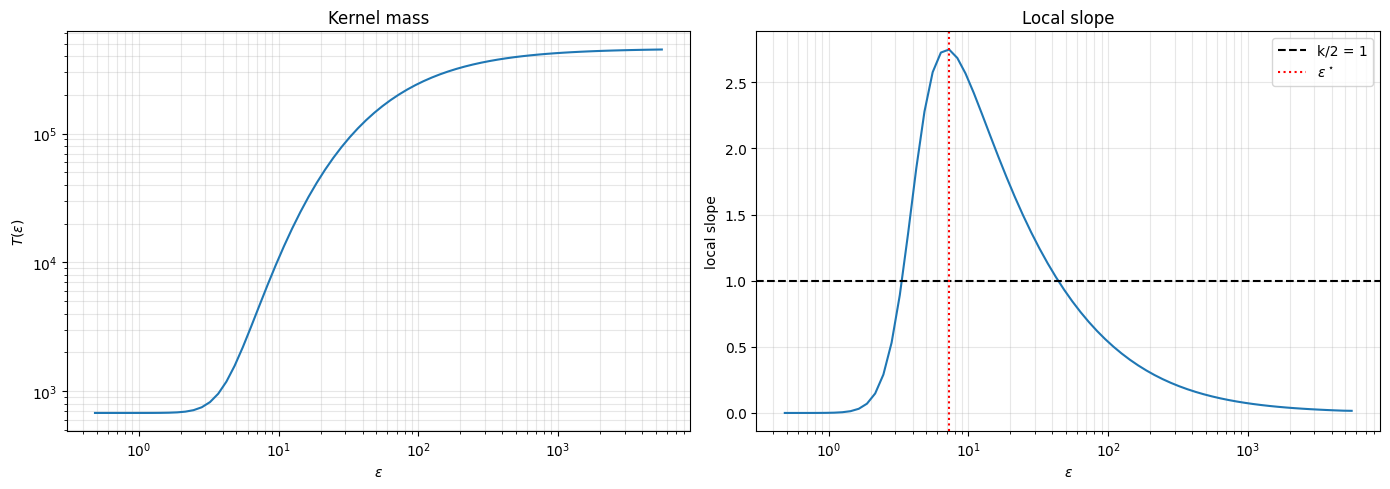

In [49]:
def diffusion_map(data, eps, alpha=1, k=4):
    Dsq = squareform(pdist(data)**2)
    Wm = np.exp(-Dsq/eps); q = Wm.sum(1)
    Wa = Wm/np.outer(q**alpha, q**alpha)
    da = Wa.sum(1); Dis = 1.0/np.sqrt(da)
    S = Dis[:, None]*Wa*Dis[None, :]                
    w, v = np.linalg.eigh(S)
    idx = np.argsort(w)[::-1]; w, v = w[idx], v[:, idx]
    phi = Dis[:, None]*v                             
    Psi = phi[:, 1:k+1]*w[1:k+1]                     
    return w, Psi, phi

def kernel_mass_slope(data, npts=70, lo=-1.5, hi=2.0):
    Dsq = squareform(pdist(data)**2); n = Dsq.shape[0]
    Dnd = Dsq.copy(); np.fill_diagonal(Dnd, np.inf)
    d_min = np.median(Dnd.min(1)); d_med = np.median(Dsq[np.triu_indices_from(Dsq, 1)])
    grid = np.logspace(np.log10(d_min)+lo, np.log10(d_med)+hi, npts)
    upper = Dsq[np.triu_indices_from(Dsq, 1)]
    T = np.array([2*np.exp(-upper/e).sum() + Dsq.shape[0] for e in grid])
    slope = np.gradient(np.log(T), np.log(grid))
    return grid, T, slope

def select_epsilon(data):
    grid, T, slope = kernel_mass_slope(data)
    i = int(np.argmax(slope))
    lo = max(i-5, 0); hi = min(i+5, len(grid)-1)
    return float(np.sqrt(grid[lo]*grid[hi])), grid, T, slope
Z0 = Z
eps_star, grid, T, slope = select_epsilon(Z0)
print(f"recovered k/2 estimate (max local slope) = {slope.max():.3f}")
print(f"eps_star (D=50, clean)                   = {eps_star:.4f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
a1.loglog(grid, T); a1.set_xlabel(r"$\varepsilon$"); a1.set_ylabel(r"$T(\varepsilon)$")
a1.set_title("Kernel mass"); a1.grid(which='both', alpha=.3)
a2.semilogx(grid, slope); a2.axhline(1, ls='--', c='k', label="k/2 = 1")
a2.axvline(eps_star, ls=':', c='r', label=r"$\varepsilon^\star$")
a2.set_xlabel(r"$\varepsilon$"); a2.set_ylabel("local slope"); a2.set_title("Local slope")
a2.legend(); a2.grid(which='both', alpha=.3); plt.tight_layout(); plt.show()

In [50]:
evals = []

epss = range(20, 85, 8)
for eps in epss:
    w, Psi, phi = diffusion_map(Z, eps=eps)
    evals.append(w[1:20])


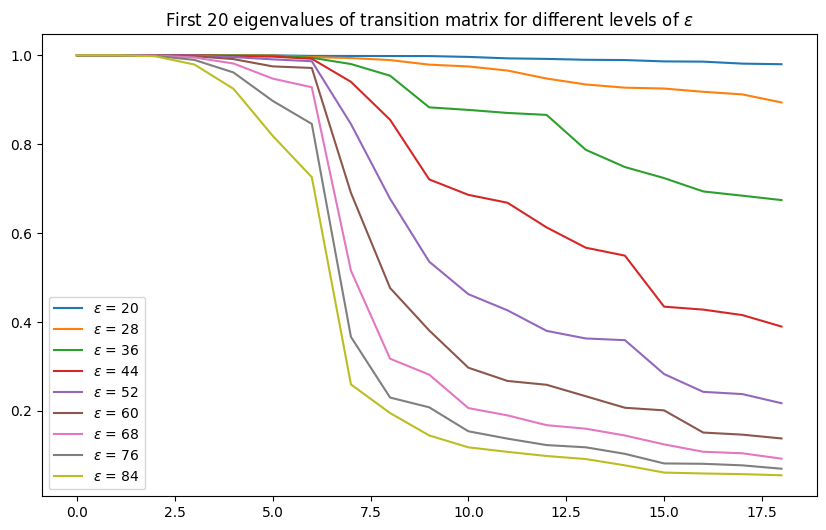

In [51]:
plt.figure(figsize=(10, 6))

for i, w in enumerate(evals):
    plt.plot(w, label=fr"$\varepsilon$ = {epss[i]}")

plt.title(r"First 20 eigenvalues of transition matrix for different levels of $\varepsilon$")
plt.legend()
plt.show()